In [1]:
import pandas as pd
import numpy as np
import pickle
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.metrics import accuracy_score,fbeta_score,classification_report
from wordcloud import WordCloud
from nltk.tokenize import word_tokenize

from nltk.corpus import stopwords
nltk.download('stopwords')
stop=stopwords.words("english")

from nltk.stem.porter import PorterStemmer
from nltk.stem import SnowballStemmer
ss = SnowballStemmer("english")
ps = PorterStemmer()

msg_df = pd.read_csv('News_Train.csv')
msg_df.shape


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\UniTECH\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


(1490, 3)

In [2]:
stop

['i',
 'me',
 'my',
 'myself',
 'we',
 'our',
 'ours',
 'ourselves',
 'you',
 "you're",
 "you've",
 "you'll",
 "you'd",
 'your',
 'yours',
 'yourself',
 'yourselves',
 'he',
 'him',
 'his',
 'himself',
 'she',
 "she's",
 'her',
 'hers',
 'herself',
 'it',
 "it's",
 'its',
 'itself',
 'they',
 'them',
 'their',
 'theirs',
 'themselves',
 'what',
 'which',
 'who',
 'whom',
 'this',
 'that',
 "that'll",
 'these',
 'those',
 'am',
 'is',
 'are',
 'was',
 'were',
 'be',
 'been',
 'being',
 'have',
 'has',
 'had',
 'having',
 'do',
 'does',
 'did',
 'doing',
 'a',
 'an',
 'the',
 'and',
 'but',
 'if',
 'or',
 'because',
 'as',
 'until',
 'while',
 'of',
 'at',
 'by',
 'for',
 'with',
 'about',
 'against',
 'between',
 'into',
 'through',
 'during',
 'before',
 'after',
 'above',
 'below',
 'to',
 'from',
 'up',
 'down',
 'in',
 'out',
 'on',
 'off',
 'over',
 'under',
 'again',
 'further',
 'then',
 'once',
 'here',
 'there',
 'when',
 'where',
 'why',
 'how',
 'all',
 'any',
 'both',
 'each

In [3]:
msg_df = pd.read_csv('News_Train.csv')
msg_df.shape
msg_df.head(5)

,ArticleId,Text,Category
0,1833,worldcom ex-boss launches defence lawyers defe...,business
1,154,german business confidence slides german busin...,business
2,1101,bbc poll indicates economic gloom citizens in ...,business
3,1976,lifestyle governs mobile choice faster bett...,tech
4,917,enron bosses in $168m payout eighteen former e...,business


In [4]:
msg_df.describe()

,ArticleId
count,1490.000000
mean,1119.696644
std,641.826283
min,2.000000
25%,565.250000
50%,1112.500000
75%,1680.750000
max,2224.000000


In [5]:
msg_df.groupby('Category').describe().T

Category            business  entertainment     politics        sport  \
ArticleId count   336.000000     273.000000   274.000000   346.000000   
          mean   1104.315476    1100.274725  1134.317518  1104.057803   
          std     658.063510     615.695597   637.628980   649.542516   
          min       2.000000      10.000000     7.000000     4.000000   
          25%     476.250000     601.000000   610.000000   513.500000   
          50%    1107.500000    1081.000000  1163.000000  1070.000000   
          75%    1716.250000    1611.000000  1681.500000  1689.500000   
          max    2221.000000    2223.000000  2224.000000  2219.000000   

Category                tech  
ArticleId count   261.000000  
          mean   1165.195402  
          std     643.852459  
          min      20.000000  
          25%     631.000000  
          50%    1147.000000  
          75%    1755.000000  
          max    2216.000000

In [6]:
msg_df["Category"].value_counts()

Category
sport            346
business         336
politics         274
entertainment    273
tech             261
Name: count, dtype: int64

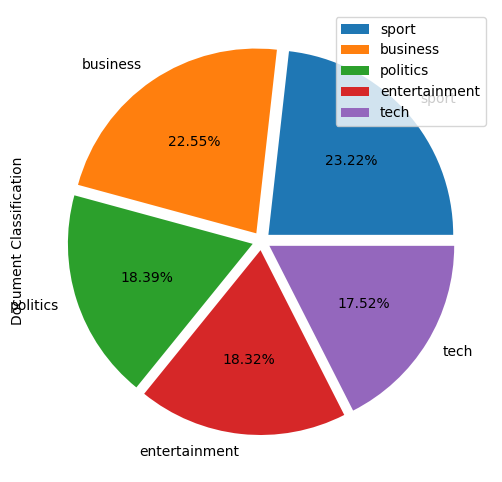

In [7]:
msg_df["Category"].value_counts().plot(kind = 'pie', explode = [0.05, 0.05, 0.05, 0.05,0.05], figsize = (6, 6), autopct = '%1.2f%%')
plt.ylabel("Document Classification")
plt.legend(["sport", "business","politics","entertainment","tech"])
plt.show()

In [8]:
msg_df.groupby("Text")["Category"].agg([len, np.max]).sort_values(by = "len", ascending = False).head(n = 10)

C:\Users\UniTECH\AppData\Local\Temp\ipykernel_8152\2119541727.py:1: FutureWarning: The provided callable <function max at 0x000001645EB734C0> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  msg_df.groupby("Text")["Category"].agg([len, np.max]).sort_values(by = "len", ascending = False).head(n = 10)


,len,max
Text,,
britons fed up with net service a survey conducted by pc pro magazine has revealed that many britons are unhappy with their internet service. they are fed up with slow speeds high prices and the level of customer service they receive. 17% of readers have switched suppliers and a further 16% are considering changing in the near future. it is particularly bad news for bt the uk s biggest internet supplier with almost three times as many people trying to leave as joining. a third of the 2 000 broadband users interviewed were fed up with their current providers but this could be just the tip of the iceberg thinks tim danton editor of pc pro magazine. we expect these figures to leap in 2005. every month the prices drop and more and more people are trying to switch he said. the survey found that bt and tiscali have been actively dissuading customers from leaving by offering them a lower price when they phone up to cancel their subscription. some readers were offered a price drop just 25p more expensive than that offered by an alternative operator making it hardly worth while swapping. other found themselves tied into 12-month contracts. broadband has become hugely competitive and providers are desperate to hold on to customers. 12% of those surveyed found themselves unable to swap at all. we discovered a huge variety of problems but one of the biggest issues is the current supplier withholding the information that people need to give to their new supplier said tim danton editor of pc pro. this breaks the code of practice but because that code is voluntary there s nothing we or ofcom can do to help he said. there is a vast choice of internet service providers in the uk now and an often bewildering array of broadband packages. with prices set to drop even further in coming months mr danton advises everyone to shop around carefully. if you just stick with your current connection then there s every chance you re being ripped off he warned.,2,tech
de niro film leads us box office film star robert de niro has returned to the top of the north american box office with his film hide and seek. the thriller shot straight to the number one spot after taking $22m (£11.7m) at the box office. de niro recently spent three weeks at the top with comedy meet the fockers which was at number five this week. oscar hopefuls the aviator million dollar baby and sideways all cashed in on their multiple nominations with stronger ticket sales. in hide and seek de niro plays a widower whose daughter has a creepy imaginary friend. despite lukewarm reviews from critics the film took more than the expected $18m (£9.5m). the element of a real actor in a psychological thriller certainly elevated it said bruce snyder president of domestic distribution at 20th century fox. clint eastwood s million dollar baby led the oscar hopefuls with $11.8m (£6.3m) coming in at number three during its first weekend of wide release. the aviator a film biography of howard hughes that leads the oscar field with 11 nominations was at number six for the weekend with $7.5m (£4m). oscar best-picture nominee sideways entered the top ten for the first time in its 15th week of release. it came in seventh $6.3 (£3.35m). last week s top film ice cube s road-trip comedy are we there yet slipped to second place with $17m (£9m) while coach carter fell two places to number four taking $8m (£4.25m) in its third week. rounding out the top ten were in good company - starring dennis quaid and scarlett johansson - racing stripes and assault on precinct 13.,2,entertainment
blind student hears in colour a blind student has developed software that turns colours into musical notes so that he can read weather maps. victor wong a graduate student from hong kong studying at cornell university in new york state had to read coloured maps of the upper atmosphere as part of his research. to study space weather mr wong needed to explore minute fluctuations in order to create mathematical models. a 

In [9]:
msg_df['length']=msg_df['Text'].apply(len)
msg_df.head()


,ArticleId,Text,Category,length
0,1833,worldcom ex-boss launches defence lawyers defe...,business,1866
1,154,german business confidence slides german busin...,business,2016
2,1101,bbc poll indicates economic gloom citizens in ...,business,3104
3,1976,lifestyle governs mobile choice faster bett...,tech,3618
4,917,enron bosses in $168m payout eighteen former e...,business,2190


In [10]:
msg_df.length.describe()

count     1490.000000
mean      2233.461745
std       1205.153358
min        501.000000
25%       1453.000000
50%       1961.000000
75%       2751.250000
max      18387.000000
Name: length, dtype: float64

In [11]:
msg_df[msg_df['length']==910]['Text'].iloc[0]

'oil prices fall back from highs oil prices retreated from four-month highs in early trading on tuesday after producers  cartel opec said it was now unlikely to cut production.  following the comments by acting opec secretary general adnan shihab-eldin  us light crude fell 32 cents to $51.43 a barrel. he said that high oil prices meant opec was unlikely to stick to its plan to cut output in the second quarter. in london  brent crude fell 32 cents to $49.74 a barrel.  opec members are next meeting to discuss production levels on 16 march. on monday  oil prices rose for a sixth straight session  reaching a four-month high as cold weather in the us threatened stocks of heating oil. us demand for heating oil was predicted to be about 14% above normal this week  while stocks were currently about 7.5% below the levels of a year ago. cold weather across europe has also put upward pressure on crude prices.'

array([[<Axes: title={'center': 'business'}>,
        <Axes: title={'center': 'entertainment'}>],
       [<Axes: title={'center': 'politics'}>,
        <Axes: title={'center': 'sport'}>],
       [<Axes: title={'center': 'tech'}>, <Axes: >]], dtype=object)

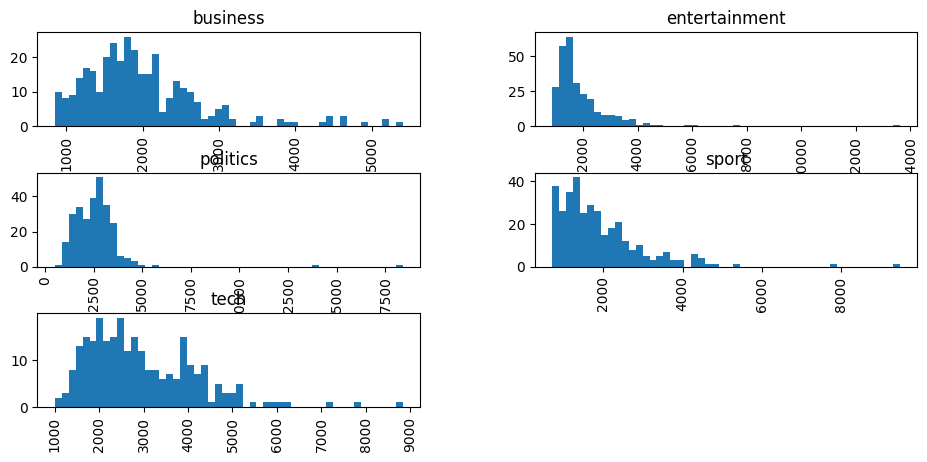

In [12]:
msg_df.hist(column='length', by='Category', bins=50,figsize=(11,5))

Looks like the lengthy is the message, more likely it is a spam. Let's not forget this


 # Text Transformation
Data Cleaning (Removing unimportant data/ Stopwords/ Stemming)

In [13]:
msg_df.head(4)

,ArticleId,Text,Category,length
0,1833,worldcom ex-boss launches defence lawyers defe...,business,1866
1,154,german business confidence slides german busin...,business,2016
2,1101,bbc poll indicates economic gloom citizens in ...,business,3104
3,1976,lifestyle governs mobile choice faster bett...,tech,3618


In [14]:
import string
def cleanText(message):
    #message = message.translate(str.maketrans('ranjan', 'ranjan', string.punctuation))
    message = re.sub('[^a-zA-Z]', ' ', message)
    message = message.lower()
    message = message.split()
    words = [ss.stem(word) for word in message if word not in stop]
    return " ".join(words)

msg_df["Text"] = msg_df["Text"].apply(cleanText)
msg_df.head(n = 10)



,ArticleId,Text,Category,length
0,1833,worldcom ex boss launch defenc lawyer defend f...,business,1866
1,154,german busi confid slide german busi confid fe...,business,2016
2,1101,bbc poll indic econom gloom citizen major nati...,business,3104
3,1976,lifestyl govern mobil choic faster better funk...,tech,3618
4,917,enron boss payout eighteen former enron direct...,business,2190
5,1582,howard truant play snooker conserv leader mich...,politics,1588
6,651,wale silent grand slam talk rhys william say w...,sport,1988
7,1797,french honour director parker british film dir...,entertainment,1342
8,2034,car giant hit merced slump slump profit luxuri...,business,2609
9,1866,focker fuel festiv film chart comedi meet fock...,entertainment,1368


In [15]:
sport_messages = msg_df[msg_df["Category"] == "sport"]["Text"]

business_messages = msg_df[msg_df["Category"] == "business"]["Text"]

politics_messages = msg_df[msg_df["Category"] == "politics"]["Text"]

entertainment_messages = msg_df[msg_df["Category"] == "entertainment"]["Text"]

tech_messages = msg_df[msg_df["Category"] == "tech"]["Text"]

In [16]:
politics_messages

5       howard truant play snooker conserv leader mich...
10      blair reject iraq advic call toni blair reject...
28      uk stand firm eu rebat britain bn eu rebat ren...
33      secur paper found street inquiri way file cont...
52      mps quiz aid royal incom senior offici two bod...
                              ...                        
1456    blair told doubl oversea aid toni blair urg us...
1463    abba toler attack palestinian leader mahmoud a...
1472    kelli trail new disciplin power teacher could ...
1475    budget set scene elect gordon brown seek put e...
1478    visa row mandarin made sir john top civil serv...
Name: Text, Length: 274, dtype: object

In [17]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\UniTECH\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [18]:
sport_words = []
business_words = []
entertainment_words = []
politics_words = []
tech_words = []


def extractSportWords(sportNews):
    global sport_words
    words = [word for word in word_tokenize(sportNews)]
    sport_words= sport_words + words
    
def extractBusinessWords(businessNews):
    global business_words
    words = [word for word in word_tokenize(businessNews) ]
    business_words = business_words + words

    
def extractPoliticsWords(politicsNews):
    global politics_words
    words = [word for word in word_tokenize(politicsNews) ]
    politics_words = politics_words + words
    
    
    
def extractEntertainmentWords(entertainmentNews):
    global entertainment_words
    words = [word for word in word_tokenize(entertainmentNews) ]
    entertainment_words = entertainment_words + words
    
    

def extractTechWords(techNews):
    global tech_words
    words = [word for word in word_tokenize(techNews) ]
    tech_words = tech_words + words
    
    
    
    
sport_messages.apply(extractSportWords)

business_messages.apply(extractBusinessWords)

politics_messages.apply(extractPoliticsWords)

entertainment_messages.apply(extractEntertainmentWords)

tech_messages.apply(extractTechWords)







3       None
19      None
24      None
26      None
30      None
        ... 
1469    None
1477    None
1482    None
1488    None
1489    None
Name: Text, Length: 261, dtype: object

In [19]:
politics_words

['howard',
 'truant',
 'play',
 'snooker',
 'conserv',
 'leader',
 'michael',
 'howard',
 'admit',
 'use',
 'play',
 'truant',
 'spend',
 'time',
 'school',
 'friend',
 'snooker',
 'hall',
 'mr',
 'howard',
 'said',
 'time',
 'jack',
 'snooker',
 'hall',
 'llanelli',
 'done',
 'last',
 'damag',
 'told',
 'time',
 'educ',
 'supplement',
 'truanci',
 'bad',
 'said',
 'firm',
 'action',
 'need',
 'mr',
 'howard',
 'also',
 'call',
 'return',
 'level',
 'classroom',
 'disciplin',
 'mr',
 'howard',
 'eventu',
 'left',
 'llanelli',
 'grammar',
 'school',
 'snooker',
 'hall',
 'go',
 'cambridg',
 'univers',
 'said',
 'think',
 'done',
 'last',
 'damag',
 'made',
 'snooker',
 'world',
 'champion',
 'might',
 'occas',
 'left',
 'earli',
 'afternoon',
 'honest',
 'think',
 'truanci',
 'bad',
 'thing',
 'firm',
 'action',
 'taken',
 'deal',
 'anoth',
 'player',
 'fail',
 'win',
 'snooker',
 'world',
 'championship',
 'jimmi',
 'whirlwind',
 'white',
 'previous',
 'admit',
 'miss',
 'lesson',
 'in

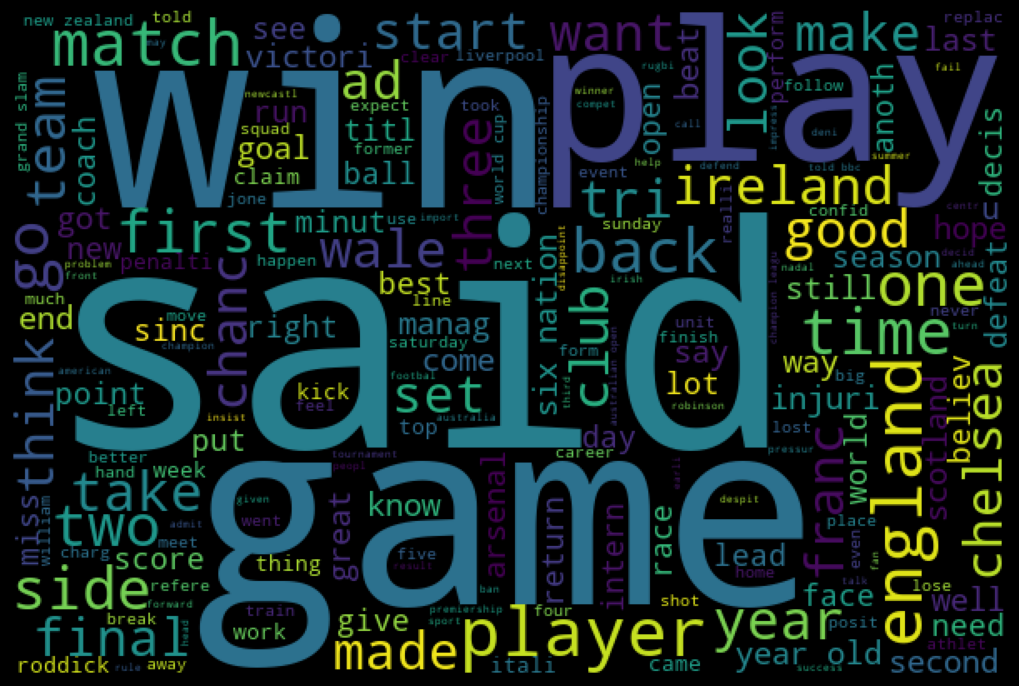

In [20]:
sport_wordcloud = WordCloud(width=600, height=400).generate(" ".join(sport_words))
plt.figure( figsize=(10,8), facecolor='k')
plt.imshow(sport_wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

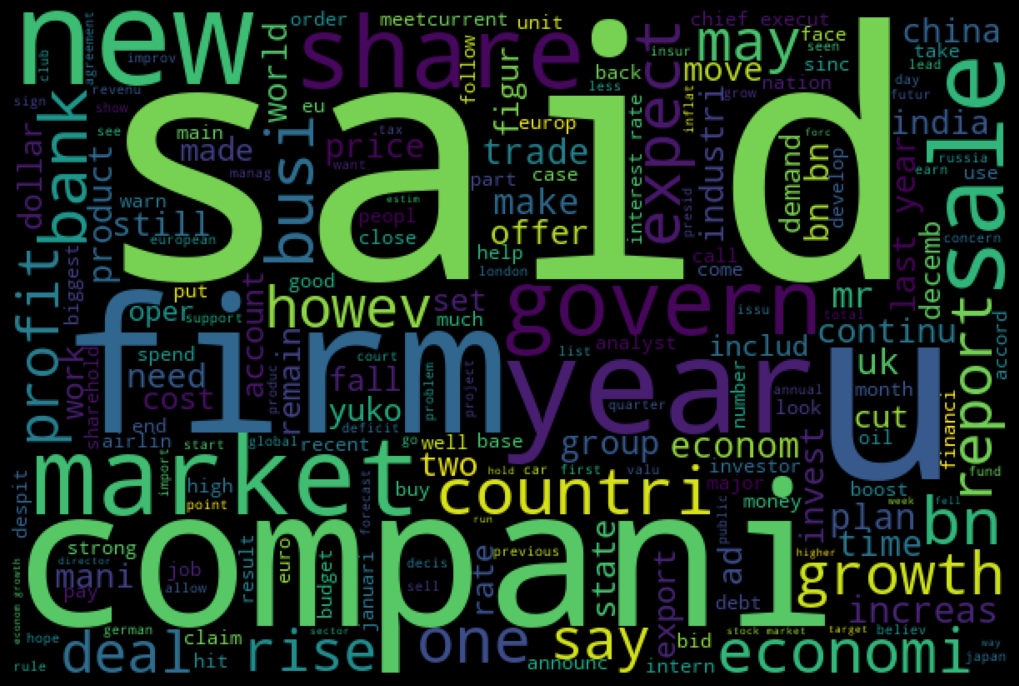

In [21]:
business_wordcloud = WordCloud(width=600, height=400).generate(" ".join(business_words))
plt.figure( figsize=(10,8), facecolor='k')
plt.imshow(business_wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()



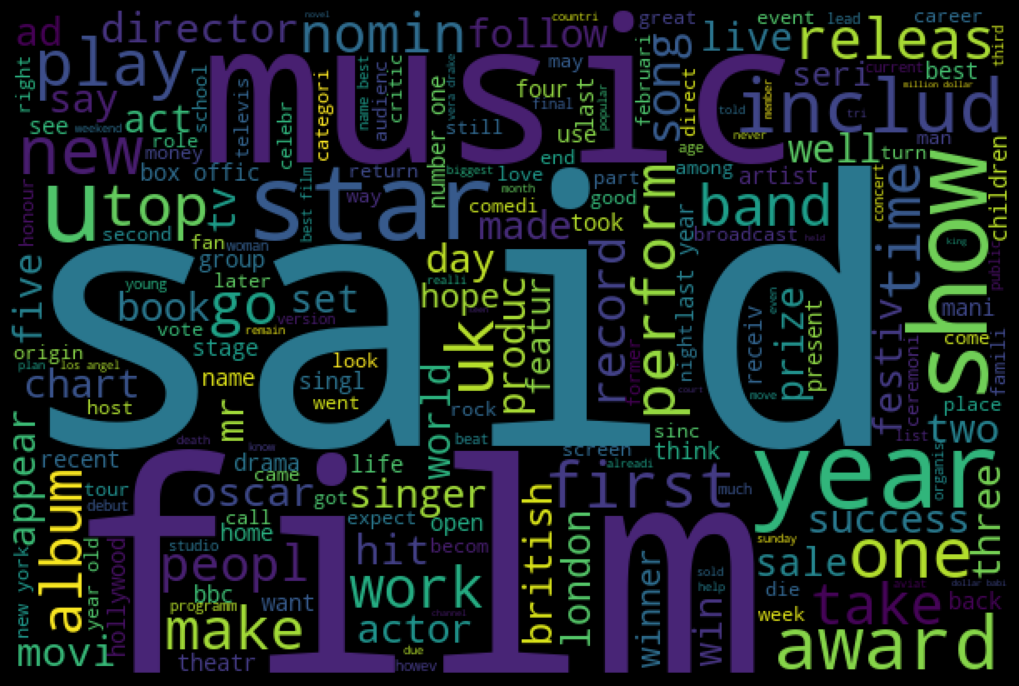

In [22]:
entertainment_wordcloud = WordCloud(width=600, height=400).generate(" ".join(entertainment_words))
plt.figure( figsize=(10,8), facecolor='k')
plt.imshow(entertainment_wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()


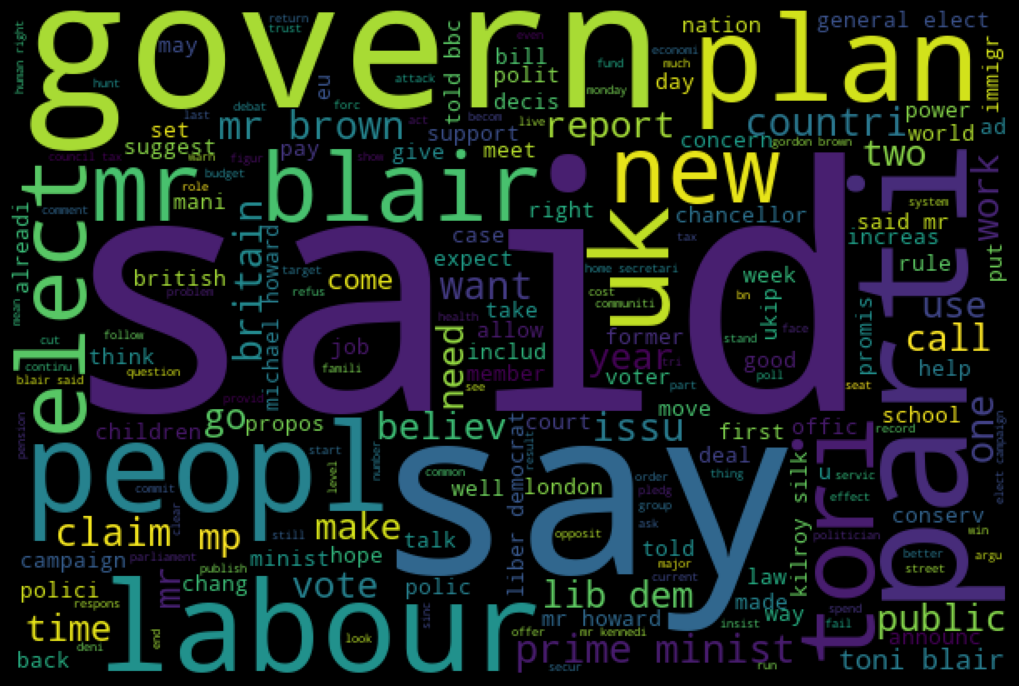

In [23]:
politics_wordcloud = WordCloud(width=600, height=400).generate(" ".join(politics_words))
plt.figure( figsize=(10,8), facecolor='k')
plt.imshow(politics_wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

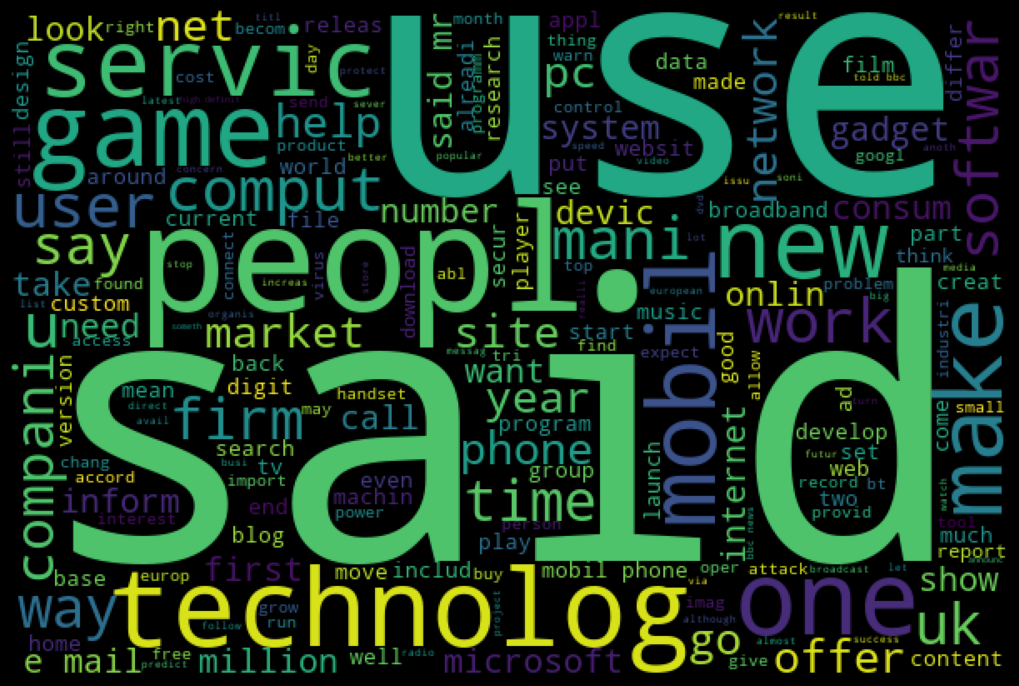

In [24]:
tech_wordcloud = WordCloud(width=600, height=400).generate(" ".join(tech_words))
plt.figure( figsize=(10,8), facecolor='k')
plt.imshow(tech_wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

In [25]:
msg_df

,ArticleId,Text,Category,length
0,1833,worldcom ex boss launch defenc lawyer defend f...,business,1866
1,154,german busi confid slide german busi confid fe...,business,2016
2,1101,bbc poll indic econom gloom citizen major nati...,business,3104
3,1976,lifestyl govern mobil choic faster better funk...,tech,3618
4,917,enron boss payout eighteen former enron direct...,business,2190
...,...,...,...,...
1485,857,doubl evict big brother model capric holbi cit...,entertainment,1266
1486,325,dj doubl act revamp chart show dj duo jk joel ...,entertainment,3111
1487,1590,weak dollar hit reuter revenu media group reut...,business,1370
1488,1587,appl ipod famili expand market appl expand ipo...,tech,3242


In [26]:
def encodeCategory(cat):
    if cat == "sport":
        return 1
    elif cat == "business":
        return 2
    elif cat == "politics":
        return 3
    elif cat == "entertainment":
        return 4
    elif cat == "tech":
        return 5
    else:
        return 0
        
msg_df["Category"] = msg_df["Category"].apply(encodeCategory)

In [27]:
msg_df

,ArticleId,Text,Category,length
0,1833,worldcom ex boss launch defenc lawyer defend f...,2,1866
1,154,german busi confid slide german busi confid fe...,2,2016
2,1101,bbc poll indic econom gloom citizen major nati...,2,3104
3,1976,lifestyl govern mobil choic faster better funk...,5,3618
4,917,enron boss payout eighteen former enron direct...,2,2190
...,...,...,...,...
1485,857,doubl evict big brother model capric holbi cit...,4,1266
1486,325,dj doubl act revamp chart show dj duo jk joel ...,4,3111
1487,1590,weak dollar hit reuter revenu media group reut...,2,1370
1488,1587,appl ipod famili expand market appl expand ipo...,5,3242



Lets convert our clean text into a representation that a machine learning model can understand.
Bag of Words
Techiniques are :
#TFIDF
#Count Vectorizer


In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer
vec = TfidfVectorizer(encoding = "latin-1", strip_accents = "unicode")
features = vec.fit_transform(msg_df["Text"])
print(features.shape)

(1490, 15883)


In [29]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer()
X=cv.fit_transform(msg_df["Text"])
print (X.shape)

(1490, 15883)


In [30]:
#cv = CountVectorizer()

#X=cv.fit(msg_df["Text"])
#X.vocabulary_
#X.get_feature_names()

In [31]:
cv = CountVectorizer()

X = cv.fit(msg_df["Text"])

# Access the vocabulary of CountVectorizer
vocab = cv.get_feature_names_out()

# This will give you the feature names as a list
print(vocab)


['aa' 'aaa' 'aac' ... 'zurich' 'zuton' 'zvonareva']


In [32]:
X = cv.fit_transform(msg_df["Text"]).toarray()
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [33]:
#df = pd.DataFrame(X,columns=cv.get_feature_names())
#df
#df['len']=msg_df['length']
#df

In [34]:
df = pd.DataFrame(X, columns=vocab)

# Assuming msg_df['length'] is the length of each text entry in your original DataFrame
df['len'] = msg_df['length']


# Display the DataFrame
df

,aa,aaa,aac,aadc,aaliyah,aaltra,aamir,aaron,abacus,abandon,...,zombi,zone,zonealarm,zoom,zooropa,zorro,zuluaga,zurich,zuton,zvonareva
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1485,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1486,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1487,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1488,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [35]:
df

,aa,aaa,aac,aadc,aaliyah,aaltra,aamir,aaron,abacus,abandon,...,zombi,zone,zonealarm,zoom,zooropa,zorro,zuluaga,zurich,zuton,zvonareva
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1485,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1486,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1487,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1488,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [36]:
print(X)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [37]:
df.head()

,aa,aaa,aac,aadc,aaliyah,aaltra,aamir,aaron,abacus,abandon,...,zombi,zone,zonealarm,zoom,zooropa,zorro,zuluaga,zurich,zuton,zvonareva
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [38]:
y=msg_df['Category']

In [40]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df, y, test_size = 0.2, random_state = 0)

# Training model using Naive bayes classifier

from sklearn.naive_bayes import MultinomialNB
news_detect_model = MultinomialNB().fit(X_train, y_train)

y_pred=news_detect_model.predict(X_test)

In [41]:
print(accuracy_score(y_test,y_pred))
#print(fbeta_score(y_test,y_pred,beta =0.5))


0.9664429530201343


In [42]:
y_pred

array([4, 3, 1, 3, 1, 2, 2, 5, 4, 2, 1, 4, 3, 5, 1, 5, 2, 4, 5, 4, 5, 5,
       4, 5, 2, 2, 3, 1, 4, 5, 4, 1, 5, 4, 4, 2, 2, 2, 5, 5, 1, 2, 3, 2,
       3, 4, 1, 4, 5, 1, 3, 1, 4, 1, 1, 4, 4, 3, 1, 4, 1, 5, 1, 2, 4, 5,
       2, 5, 2, 4, 1, 1, 4, 5, 5, 3, 3, 3, 4, 5, 5, 5, 4, 4, 5, 1, 5, 2,
       2, 2, 2, 2, 3, 5, 3, 1, 2, 5, 4, 3, 4, 2, 2, 1, 3, 2, 1, 5, 3, 2,
       4, 4, 3, 3, 4, 4, 4, 4, 5, 3, 3, 2, 3, 1, 5, 5, 1, 1, 1, 1, 1, 1,
       2, 3, 3, 1, 1, 5, 1, 3, 2, 1, 3, 2, 4, 2, 5, 4, 3, 5, 1, 1, 1, 3,
       1, 1, 2, 4, 4, 2, 4, 2, 1, 2, 1, 1, 2, 3, 1, 2, 2, 4, 1, 4, 2, 4,
       5, 3, 2, 4, 5, 5, 5, 3, 5, 1, 2, 2, 4, 1, 3, 4, 3, 5, 2, 3, 3, 1,
       4, 3, 2, 1, 5, 3, 1, 2, 1, 4, 2, 5, 4, 2, 2, 5, 2, 3, 5, 4, 1, 3,
       4, 4, 5, 3, 2, 2, 3, 5, 4, 1, 1, 3, 3, 5, 3, 5, 4, 4, 5, 3, 4, 2,
       1, 1, 1, 5, 2, 3, 4, 3, 2, 5, 5, 2, 3, 1, 3, 3, 2, 4, 2, 5, 1, 5,
       1, 2, 2, 3, 5, 3, 3, 3, 2, 5, 3, 1, 3, 5, 4, 5, 2, 5, 3, 4, 4, 1,
       1, 2, 2, 4, 5, 4, 1, 1, 5, 4, 4, 3])

In [43]:
print (classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           1       1.00      0.95      0.98        65
           2       1.00      0.95      0.98        64
           3       0.93      1.00      0.96        53
           4       0.98      0.94      0.96        63
           5       0.91      1.00      0.95        53

    accuracy                           0.97       298
   macro avg       0.97      0.97      0.97       298
weighted avg       0.97      0.97      0.97       298



In [44]:
from sklearn.metrics import confusion_matrix, classification_report

# Assuming y_test and y_pred are defined
conf_matrix = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Confusion Matrix:")
print(conf_matrix)

#print("\nClassification Report:")
#print(report)

Confusion Matrix:
[[62  0  2  1  0]
 [ 0 61  1  0  2]
 [ 0  0 53  0  0]
 [ 0  0  1 59  3]
 [ 0  0  0  0 53]]


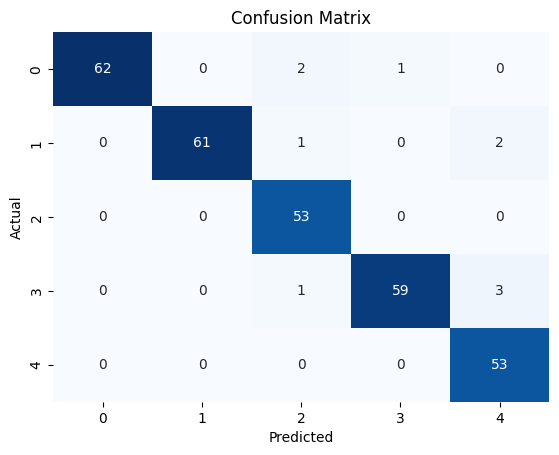

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Assuming y_test and y_pred are defined
conf_matrix = confusion_matrix(y_test, y_pred)

# Create a heatmap
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB

<h1>Random Forest Classifier</h1>

In [47]:
classifier = RandomForestClassifier() 
classifier.fit(X_train, y_train) 

RandomForestClassifier()

In [48]:
y_pred=classifier.predict(X_test)

In [49]:
print(accuracy_score(y_test,y_pred))
#print(fbeta_score(y_test,y_pred,beta =0.5))


0.9563758389261745


In [50]:
y_pred

array([4, 3, 1, 3, 1, 2, 2, 5, 4, 2, 1, 4, 3, 5, 1, 5, 2, 4, 2, 4, 5, 5,
       4, 5, 2, 2, 3, 1, 4, 5, 4, 1, 2, 4, 4, 2, 2, 2, 2, 5, 1, 2, 3, 2,
       1, 4, 1, 4, 5, 1, 3, 1, 4, 1, 1, 4, 4, 3, 1, 4, 1, 5, 1, 2, 1, 5,
       2, 5, 2, 4, 1, 1, 4, 5, 5, 3, 3, 3, 4, 5, 5, 5, 4, 4, 4, 1, 5, 2,
       2, 2, 2, 2, 3, 4, 3, 1, 2, 5, 4, 2, 4, 2, 2, 1, 3, 2, 1, 5, 3, 2,
       4, 4, 3, 3, 4, 4, 4, 4, 5, 3, 3, 2, 3, 1, 5, 5, 1, 1, 1, 1, 1, 1,
       2, 3, 1, 1, 1, 5, 1, 3, 2, 1, 3, 2, 4, 2, 5, 4, 3, 5, 1, 1, 1, 3,
       1, 1, 2, 4, 4, 2, 4, 2, 1, 2, 1, 1, 2, 3, 1, 2, 2, 4, 1, 4, 2, 2,
       5, 3, 2, 4, 5, 5, 5, 3, 5, 1, 2, 2, 4, 1, 3, 4, 3, 5, 2, 3, 3, 1,
       4, 3, 2, 1, 5, 3, 1, 2, 1, 4, 2, 5, 4, 2, 2, 5, 2, 3, 5, 4, 1, 3,
       4, 4, 5, 3, 2, 2, 3, 5, 4, 1, 1, 3, 3, 5, 3, 5, 4, 4, 5, 3, 4, 2,
       1, 1, 1, 5, 2, 3, 4, 3, 2, 5, 5, 2, 3, 1, 3, 1, 2, 4, 2, 5, 1, 5,
       1, 2, 2, 2, 5, 3, 3, 3, 3, 1, 3, 1, 3, 4, 4, 5, 2, 5, 3, 4, 4, 1,
       1, 2, 2, 4, 2, 4, 1, 1, 5, 4, 4, 3])

In [51]:
print (classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           1       0.96      0.98      0.97        65
           2       0.94      0.98      0.96        64
           3       0.94      0.94      0.94        53
           4       0.97      0.94      0.95        63
           5       0.98      0.92      0.95        53

    accuracy                           0.96       298
   macro avg       0.96      0.95      0.96       298
weighted avg       0.96      0.96      0.96       298



In [52]:
from sklearn.metrics import confusion_matrix, classification_report

# Assuming y_test and y_pred are defined
conf_matrix = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Confusion Matrix:")
print(conf_matrix)

#print("\nClassification Report:")
#print(report)

Confusion Matrix:
[[64  0  1  0  0]
 [ 0 63  1  0  0]
 [ 2  1 50  0  0]
 [ 0  2  1 59  1]
 [ 1  1  0  2 49]]


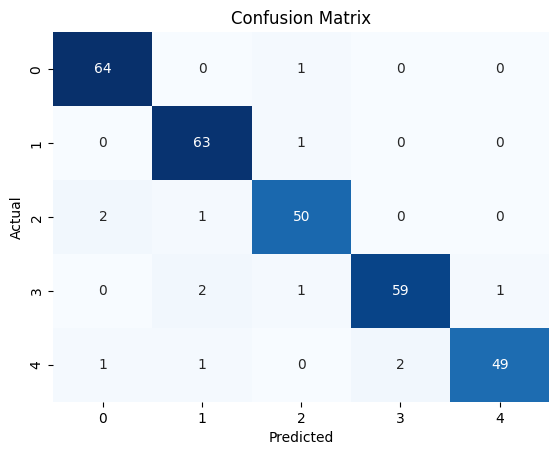

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Assuming y_test and y_pred are defined
conf_matrix = confusion_matrix(y_test, y_pred)

# Create a heatmap
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [54]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.multiclass import OneVsRestClassifier


from sklearn.metrics import classification_report
from sklearn.metrics import make_scorer, roc_curve, roc_auc_score
from sklearn.metrics import precision_recall_fscore_support as score

In [55]:
y_pred = classifier.predict(X_test)

In [56]:
# Displaying the result of predictions
print("Predicted labels for the test set:")
print(y_pred)

Predicted labels for the test set:
[4 3 1 3 1 2 2 5 4 2 1 4 3 5 1 5 2 4 2 4 5 5 4 5 2 2 3 1 4 5 4 1 2 4 4 2 2
 2 2 5 1 2 3 2 1 4 1 4 5 1 3 1 4 1 1 4 4 3 1 4 1 5 1 2 1 5 2 5 2 4 1 1 4 5
 5 3 3 3 4 5 5 5 4 4 4 1 5 2 2 2 2 2 3 4 3 1 2 5 4 2 4 2 2 1 3 2 1 5 3 2 4
 4 3 3 4 4 4 4 5 3 3 2 3 1 5 5 1 1 1 1 1 1 2 3 1 1 1 5 1 3 2 1 3 2 4 2 5 4
 3 5 1 1 1 3 1 1 2 4 4 2 4 2 1 2 1 1 2 3 1 2 2 4 1 4 2 2 5 3 2 4 5 5 5 3 5
 1 2 2 4 1 3 4 3 5 2 3 3 1 4 3 2 1 5 3 1 2 1 4 2 5 4 2 2 5 2 3 5 4 1 3 4 4
 5 3 2 2 3 5 4 1 1 3 3 5 3 5 4 4 5 3 4 2 1 1 1 5 2 3 4 3 2 5 5 2 3 1 3 1 2
 4 2 5 1 5 1 2 2 2 5 3 3 3 3 1 3 1 3 4 4 5 2 5 3 4 4 1 1 2 2 4 2 4 1 1 5 4
 4 3]


In [57]:
from sklearn.metrics import accuracy_score

# Assuming y_true contains the true labels of the test set
# and y_pred contains the predicted labels from your classifier

# Calculating the classification accuracy
classification_accuracy = accuracy_score(y_test, y_pred)

# Displaying the classification accuracy
print("Classification Accuracy:", classification_accuracy)

Classification Accuracy: 0.9563758389261745


<h1>Decision Tree Classifier</h1>

In [58]:
classifier_dt = RandomForestClassifier() 
classifier_dt.fit(X_train, y_train) 

RandomForestClassifier()

In [59]:
y_pred=classifier_dt.predict(X_test)

In [60]:
print(accuracy_score(y_test,y_pred))

0.9630872483221476


In [61]:
y_pred

array([4, 3, 1, 3, 1, 2, 2, 5, 4, 2, 1, 4, 3, 5, 1, 5, 2, 4, 5, 4, 5, 5,
       4, 5, 2, 2, 3, 1, 4, 5, 4, 1, 3, 4, 4, 2, 2, 2, 2, 5, 1, 2, 3, 2,
       1, 4, 1, 4, 5, 1, 3, 1, 4, 1, 1, 4, 4, 3, 1, 4, 1, 5, 1, 2, 1, 5,
       2, 5, 2, 4, 1, 1, 4, 5, 5, 3, 3, 3, 4, 5, 5, 5, 4, 4, 5, 1, 5, 2,
       2, 2, 2, 2, 3, 4, 3, 1, 2, 5, 4, 2, 4, 2, 2, 1, 3, 2, 1, 5, 3, 2,
       4, 4, 3, 3, 4, 4, 4, 4, 5, 3, 3, 2, 3, 1, 4, 5, 1, 1, 1, 1, 1, 1,
       2, 3, 1, 1, 1, 5, 1, 3, 2, 1, 3, 2, 4, 2, 5, 4, 3, 5, 1, 1, 1, 3,
       1, 1, 2, 4, 4, 2, 4, 2, 1, 2, 1, 1, 2, 3, 1, 2, 2, 4, 1, 4, 2, 4,
       5, 3, 2, 4, 5, 5, 5, 3, 5, 1, 2, 2, 4, 1, 3, 4, 3, 5, 2, 3, 3, 1,
       4, 1, 2, 1, 5, 3, 1, 2, 1, 4, 2, 5, 4, 2, 2, 5, 2, 3, 5, 1, 1, 3,
       4, 4, 5, 3, 2, 2, 3, 5, 4, 1, 1, 3, 3, 5, 3, 5, 4, 4, 5, 3, 4, 2,
       1, 1, 1, 5, 2, 3, 4, 3, 2, 5, 5, 2, 3, 1, 3, 4, 2, 4, 2, 5, 1, 5,
       1, 2, 2, 2, 5, 3, 3, 3, 2, 1, 3, 1, 3, 5, 4, 5, 2, 5, 3, 4, 4, 1,
       1, 2, 2, 4, 2, 4, 1, 1, 5, 4, 4, 3])

In [62]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           1       0.94      0.98      0.96        65
           2       0.97      0.98      0.98        64
           3       0.94      0.92      0.93        53
           4       0.98      0.95      0.97        63
           5       0.98      0.96      0.97        53

    accuracy                           0.96       298
   macro avg       0.96      0.96      0.96       298
weighted avg       0.96      0.96      0.96       298



In [63]:
from sklearn.metrics import confusion_matrix, classification_report

# Assuming y_test and y_pred are defined
conf_matrix = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Confusion Matrix:")
print(conf_matrix)

#print("\nClassification Report:")
#print(report)

Confusion Matrix:
[[64  0  1  0  0]
 [ 0 63  0  0  1]
 [ 2  1 49  1  0]
 [ 1  0  2 60  0]
 [ 1  1  0  0 51]]


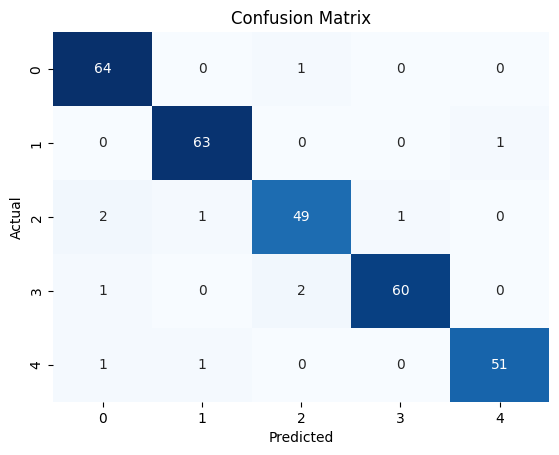

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Assuming y_test and y_pred are defined
conf_matrix = confusion_matrix(y_test, y_pred)

# Create a heatmap
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

 <h1>Support Vector Machine</h1>

In [65]:
classifier_svc = SVC()
classifier_svc.fit(X_train, y_train) 

SVC()

In [66]:
y_pred=classifier_svc.predict(X_test)

In [67]:
print(accuracy_score(y_test,y_pred))

0.31543624161073824


In [68]:
y_pred

array([2, 2, 1, 5, 2, 2, 3, 5, 1, 2, 2, 1, 3, 3, 5, 5, 2, 1, 2, 2, 3, 3,
       2, 2, 2, 2, 3, 2, 1, 2, 2, 5, 3, 2, 3, 3, 2, 2, 2, 2, 2, 3, 3, 2,
       2, 2, 1, 1, 2, 2, 3, 2, 3, 1, 1, 5, 2, 2, 2, 2, 3, 5, 2, 2, 1, 3,
       2, 2, 2, 2, 2, 2, 2, 3, 2, 2, 3, 5, 2, 5, 2, 3, 2, 3, 2, 3, 5, 3,
       5, 3, 2, 2, 2, 2, 3, 2, 1, 3, 2, 2, 2, 3, 2, 3, 2, 3, 2, 3, 3, 2,
       2, 2, 2, 5, 1, 3, 3, 2, 2, 2, 2, 2, 2, 3, 3, 3, 2, 2, 2, 2, 1, 5,
       2, 3, 2, 2, 1, 2, 2, 2, 5, 1, 2, 2, 2, 1, 3, 3, 3, 3, 1, 2, 5, 3,
       2, 2, 3, 2, 2, 2, 1, 2, 1, 2, 3, 2, 3, 2, 1, 2, 1, 1, 2, 2, 2, 2,
       3, 3, 3, 5, 5, 5, 2, 2, 2, 3, 2, 2, 2, 2, 2, 2, 3, 3, 2, 2, 2, 2,
       2, 3, 3, 2, 5, 2, 2, 2, 1, 1, 2, 2, 1, 2, 2, 3, 3, 3, 2, 2, 1, 3,
       2, 2, 3, 2, 1, 2, 1, 3, 3, 3, 1, 2, 3, 3, 3, 3, 1, 1, 5, 3, 2, 2,
       3, 2, 3, 5, 1, 3, 2, 5, 2, 5, 2, 1, 2, 2, 5, 2, 2, 2, 2, 5, 2, 3,
       1, 2, 2, 3, 3, 2, 3, 3, 3, 2, 3, 2, 2, 2, 3, 5, 2, 2, 1, 2, 2, 2,
       3, 2, 2, 1, 2, 1, 1, 1, 3, 2, 2, 2])

In [69]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           1       0.44      0.26      0.33        65
           2       0.27      0.66      0.38        64
           3       0.29      0.42      0.34        53
           4       0.00      0.00      0.00        63
           5       0.50      0.25      0.33        53

    accuracy                           0.32       298
   macro avg       0.30      0.32      0.28       298
weighted avg       0.29      0.32      0.27       298



C:\MediaNewsApp\apps\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\MediaNewsApp\apps\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\MediaNewsApp\apps\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [70]:
from sklearn.metrics import confusion_matrix, classification_report

# Assuming y_test and y_pred are defined
conf_matrix = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Confusion Matrix:")
print(conf_matrix)

#print("\nClassification Report:")
#print(report)

Confusion Matrix:
[[17 34 10  0  4]
 [ 6 42 14  0  2]
 [ 2 24 22  0  5]
 [14 37 10  0  2]
 [ 0 19 21  0 13]]


C:\MediaNewsApp\apps\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\MediaNewsApp\apps\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\MediaNewsApp\apps\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


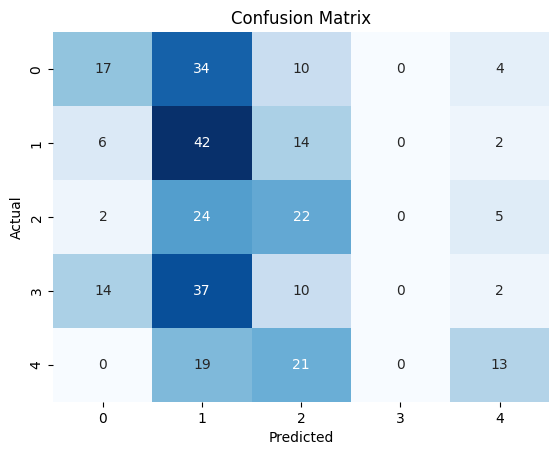

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Assuming y_test and y_pred are defined
conf_matrix = confusion_matrix(y_test, y_pred)

# Create a heatmap
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [72]:
perform_list = [ ]

In [73]:
def run_model(model_name, est_c, est_pnlty):

    mdl = ''

    if model_name == 'Logistic Regression':
        mdl = LogisticRegression()

    elif model_name == 'Random Forest':
        mdl = RandomForestClassifier(n_estimators=100, criterion='entropy', random_state=0)

    elif model_name == 'Multinomial Naive Bayes':
        mdl = MultinomialNB(alpha=1.0, fit_prior=True)

    elif model_name == 'Support Vector Classifier':
        mdl = SVC()

    elif model_name == 'Decision Tree Classifier':
        mdl = DecisionTreeClassifier()

    elif model_name == 'K Nearest Neighbour':
        mdl = KNeighborsClassifier(n_neighbors=10, metric='minkowski', p=4)

    elif model_name == 'Gaussian Naive Bayes':
        mdl = GaussianNB()

    oneVsRest = OneVsRestClassifier(mdl)
    oneVsRest.fit(X_train, y_train)
    y_pred = oneVsRest.predict(X_test)

    # Performance metrics
    accuracy = round(accuracy_score(y_test, y_pred) * 100, 2)

    # Get precision, recall, f1 scores
    precision, recall, f1score, support = score(y_test, y_pred, average='micro')

    print(f'Test Accuracy Score of Basic {model_name}: % {accuracy}')
    print(f'Precision : {precision}')
    print(f'Recall : {recall}')
    print(f'F1-score : {f1score}')

    # Add performance parameters to list
    perform_list.append({
        'Model': model_name,
        'Test Accuracy': round(accuracy, 2),
        'Precision': round(precision, 2),
        'Recall': round(recall, 2),
        'F1': round(f1score, 2)
    })

In [74]:
#run_model('Logistic Regression', est_c=None, est_pnlty=None)

In [75]:
run_model('Random Forest', est_c=None, est_pnlty=None)

Test Accuracy Score of Basic Random Forest: % 95.97
Precision : 0.959731543624161
Recall : 0.959731543624161
F1-score : 0.959731543624161


In [76]:
run_model('Multinomial Naive Bayes', est_c=None, est_pnlty=None)

Test Accuracy Score of Basic Multinomial Naive Bayes: % 97.32
Precision : 0.9731543624161074
Recall : 0.9731543624161074
F1-score : 0.9731543624161074


In [77]:
run_model('Decision Tree Classifier', est_c=None, est_pnlty=None)

Test Accuracy Score of Basic Decision Tree Classifier: % 81.21
Precision : 0.8120805369127517
Recall : 0.8120805369127517
F1-score : 0.8120805369127517


In [78]:
run_model('K Nearest Neighbour', est_c=None, est_pnlty=None)

Test Accuracy Score of Basic K Nearest Neighbour: % 32.55
Precision : 0.32550335570469796
Recall : 0.32550335570469796
F1-score : 0.32550335570469796


In [79]:
run_model('Gaussian Naive Bayes', est_c=None, est_pnlty=None)

Test Accuracy Score of Basic Gaussian Naive Bayes: % 87.92
Precision : 0.8791946308724832
Recall : 0.8791946308724832
F1-score : 0.8791946308724832


In [80]:
model_performance = pd.DataFrame(data=perform_list)
model_performance = model_performance[['Model', 'Test Accuracy', 'Precision', 'Recall', 'F1']]
model_performance

,Model,Test Accuracy,Precision,Recall,F1
0,Random Forest,95.97,0.96,0.96,0.96
1,Multinomial Naive Bayes,97.32,0.97,0.97,0.97
2,Decision Tree Classifier,81.21,0.81,0.81,0.81
3,K Nearest Neighbour,32.55,0.33,0.33,0.33
4,Gaussian Naive Bayes,87.92,0.88,0.88,0.88


In [82]:
model = model_performance["Model"]
max_value = model_performance["Test Accuracy"].max()
print("The best accuracy of model is", max_value,"from Random")

The best accuracy of model is 97.32 from Random


In [85]:
classifier =  classifier_dt.fit(X_train, y_train) 
classifier
y_pred = classifier.predict(X_test)

In [86]:
y_pred1 = cv.transform(['Hour ago, I contemplated retirement for a lot of reasons. I felt like people were not sensitive enough to my injuries. I felt like a lot of people were backed, why not me? I have done no less. I have won a lot of games for the team, and I am not feeling backed, said Ashwin'])
yy = classifier.predict(y_pred1)
result = ""
if yy == [0]:
    result = "Business News"
elif yy == [1]:
    result = "Tech News"
elif yy == [2]:
    result = "Politics News"
elif yy == [3]:
    result = "Sports News"
elif yy == [1]:
    result = "Entertainment News"
print(result)




Tech News


C:\MediaNewsApp\apps\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Logistic Regression, Random Forest, Multinomial Naive Bayes, Support Vector Machine, Decision Tree, KNN, and Gaussian Naive Bayes 

In [87]:
saved_model=pickle.dumps(news_detect_model)

In [88]:
modelfrom_pickle = pickle.loads(saved_model) 

In [89]:
y_pred=modelfrom_pickle.predict(X_test)

In [90]:
print(accuracy_score(y_test,y_pred))

0.9664429530201343


In [94]:
import joblib

In [95]:
joblib.dump(saved_model,'picklenews.pkl')

['picklenews.pkl']

In [96]:
joblib.dump(X,'transformnews.pkl')

['transformnews.pkl']